### Import Necessary Libraries

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_wine

### Data Set Collection

In [8]:
wine_data_df=pd.DataFrame(data=load_wine().data,columns=load_wine().feature_names)
wine_data_df
wine_data_df["target"]=load_wine().target
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


### Data Understanding

In [9]:
wine_data_df.shape

(178, 14)

In [10]:
wine_data_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
173    False
174    False
175    False
176    False
177    False
Length: 178, dtype: bool

In [11]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [12]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

### Model Building

In [20]:
X=wine_data_df.drop(labels="target",axis=1)
y=wine_data_df["target"]

#### Standardization Technique

In [74]:
std_scaler=StandardScaler()
scaler_x=std_scaler.fit_transform(X)
scaler_x

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [89]:
X_train,X_test,y_train,y_test=train_test_split(scaler_x,y,test_size=0.20,random_state=11,shuffle=True,stratify=y)

#### K=5

In [90]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Model Testing

In [91]:
y_pred_train=knn_model.predict(X_train)
y_pred_train

array([1, 0, 2, 1, 1, 1, 0, 2, 0, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 0, 0,
       0, 0, 2, 1, 1, 0, 2, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 1, 1, 0, 2, 0,
       0, 1, 1, 1, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 2, 0, 1, 2, 0, 1, 2, 0, 1, 0, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       1, 0, 2, 0, 1, 0, 0, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2,
       0, 2, 2, 0, 2, 1, 1, 0, 2, 1])

In [92]:
y_pred_test=knn_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 2, 0, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 2, 2, 0,
       2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 2, 0, 0, 2])

In [93]:
accuracy_score(y_train,y_pred_train)

0.9788732394366197

### Model Evaluation

#### K=3 

In [94]:
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [95]:
y_pred_train=knn_model.predict(X_train)
y_pred_train

array([1, 0, 2, 1, 1, 1, 0, 2, 0, 2, 0, 2, 2, 2, 1, 1, 1, 2, 1, 0, 0, 0,
       0, 0, 2, 1, 1, 0, 2, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 1, 1, 0, 2, 0,
       0, 1, 1, 1, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 2, 0, 1, 2, 0, 1, 2, 0, 1, 0, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       1, 0, 2, 0, 1, 0, 0, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2,
       0, 2, 2, 0, 2, 1, 1, 0, 2, 1])

In [85]:
y_pred_test=knn_model.predict(X_test)
y_pred_test

array([0, 1, 1, 0, 1, 2, 0, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 2, 2, 0,
       2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 2, 0, 0, 2])

In [96]:
accuracy_score(y_train,y_pred_train)

0.971830985915493

#### Optimal Neighbour No?

In [133]:
from sklearn.model_selection import KFold,cross_val_score
k_fold=KFold(n_splits=5,shuffle=True, random_state=123)
cv_score_mean=[]

In [134]:
for i in range(3,52,2):
    knn_class=KNeighborsClassifier(n_neighbors=i)
    knn_class.fit(scaler_x,y)
    cv_mean=cross_val_score(estimator=knn_class,X=scaler_x,y=y,cv=k_fold)
    cv_score_mean.append(cv_mean.mean().round(4))

In [135]:
cv_score_mean

[np.float64(0.949),
 np.float64(0.9605),
 np.float64(0.9603),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.9605),
 np.float64(0.9605),
 np.float64(0.966),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9603),
 np.float64(0.9602),
 np.float64(0.9602),
 np.float64(0.9489),
 np.float64(0.9433),
 np.float64(0.949),
 np.float64(0.949),
 np.float64(0.9548),
 np.float64(0.9605)]

In [136]:
max(cv_score_mean)

np.float64(0.9773)

In [137]:
cv_score_mean.index(max(cv_score_mean))

10

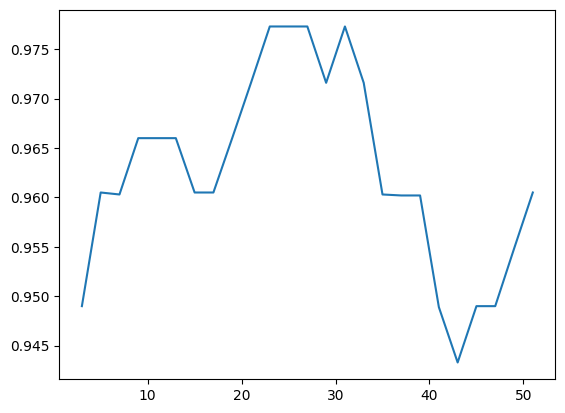

In [138]:
from matplotlib import pyplot as plt
plt.plot(range(3,52,2),cv_score_mean)
plt.show()